# Social Network Analysis - Friends

**Team members:** Lapo Chiaselotti (308291), Silvia Monteleone (315221), Riccardo Palleschi (319401), Simone Prezioso (324111)

In this notebbok, we analyzed the social network of the American TV show "Friends". Using various techniques, we explored the connections between characters to find interesting insights, such as who the most central characters are, how tightly the network is connected, and the different communities within it. By applying tools like NetworkX and visualization methods, we aimed to better understand the relationships and interactions that define the Friends network.

## How To Read This Notebook

1. Setup and reproducibility checks
2. Shared functions and data loading
3. Weekly tasks in order: 1, 2, 3, 5, 6, 7, 9, 10
4. Final validations and conclusion

In [1]:
## Imports, Setup and reproducibility

#Importing necessary libraries for data manipulation & visualization
import importlib.util
import subprocess
import sys
import random
from pathlib import Path
from itertools import combinations
import sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.preprocessing import MinMaxScaler

# Here we set a random seed for reproducibility
# This ensures that any random operations (like shuffling data, initializing model weights, etc.) will produce the same results each time the code is run
RANDOM_SEED = 42 
random.seed(RANDOM_SEED) 
np.random.seed(RANDOM_SEED)

# Pandas and Matplotlib settings for better visualization
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_rows", 20)
pd.set_option("display.precision", 6)

# Data paths and output directories
DATA_PATH = Path("data/friends_episodes.txt")
OUT_DIR = Path("out")
OUT_DIR.mkdir(exist_ok=True)

# Print environment information for verification
print("Environment ready.")
print(f"Data path: {DATA_PATH.resolve()}")
print(f"Out dir: {OUT_DIR.resolve()}")

Environment ready.
Data path: C:\Users\simon\Desktop\SNA\data\friends_episodes.txt
Out dir: C:\Users\simon\Desktop\SNA\out


## Core Reusable Functions

Added for cleaner notebook flow and to avoid repeating code across weeks. Also serves for easier validation/debugging

**Functions created:**
- `load_interactions(path) -> pd.DataFrame`
- `build_graph(df, weighted=False) -> nx.Graph`
- `largest_component_graph(G) -> nx.Graph`
- `clustering_per_node_manual(G) -> dict[str, float]`
- `average_clustering_manual(G) -> float`
- `empirical_cdf(values) -> tuple[np.ndarray, np.ndarray]`
- `neighbor_avg_clustering(G, clustering_dict) -> dict[str, float]`
- `community_partitions(G) -> dict[str, dict[str, int] | float]`
- `compute_link_scores(G) -> pd.DataFrame`
- `generate_pa_triadic(n, target_avg_degree, seed) -> nx.Graph`
- `simulate_ic(G, seeds, p, max_steps, rng_seed) -> dict`

In [2]:
def load_interactions(path: Path) -> pd.DataFrame:
    """Load valid interaction rows; skip blank and # metadata lines."""
    rows = []
    total_nonempty = 0
    skipped_malformed = 0

    with open(path, "r", encoding="utf-8") as f:
        for raw_line in f:
            line = raw_line.strip()
            if not line:
                continue

            total_nonempty += 1

            if line.startswith("#"):
                continue

            tokens = line.split()
            if len(tokens) != 2:
                skipped_malformed += 1
                continue

            rows.append((tokens[0], tokens[1]))

    df = pd.DataFrame(rows, columns=["source", "target"])
    df.attrs["total_nonempty"] = total_nonempty
    df.attrs["valid_rows"] = len(df)
    df.attrs["skipped_malformed"] = skipped_malformed
    return df


def build_graph(df: pd.DataFrame, weighted: bool = False) -> nx.Graph:
    """Build an undirected graph from interaction rows."""
    G = nx.Graph()
    if weighted:
        for source, target in df[["source", "target"]].itertuples(
            index=False, name=None
        ):
            u, v = (source, target) if source <= target else (target, source)
            if G.has_edge(u, v):
                G[u][v]["weight"] += 1
            else:
                G.add_edge(u, v, weight=1)
    else:
        G.add_edges_from(
            df[["source", "target"]].itertuples(index=False, name=None)
        )
    return G


def largest_component_graph(G: nx.Graph) -> nx.Graph:
    """Return largest connected component as a copy."""
    if G.number_of_nodes() == 0:
        return G.copy()
    lcc_nodes = max(nx.connected_components(G), key=len)
    return G.subgraph(lcc_nodes).copy()


def clustering_per_node_manual(G: nx.Graph) -> dict[str, float]:
    """Manual local clustering coefficient for each node."""
    output = {}
    for node in G.nodes():
        neigh = list(G.neighbors(node))
        k = len(neigh)
        if k < 2:
            output[node] = 0.0
            continue

        closed_triplets = 0
        for i, u in enumerate(neigh):
            for v in neigh[i + 1 :]:
                if G.has_edge(u, v):
                    closed_triplets += 1

        output[node] = (2.0 * closed_triplets) / (k * (k - 1))
    return output


def average_clustering_manual(G: nx.Graph) -> float:
    coeffs = clustering_per_node_manual(G)
    return float(np.mean(list(coeffs.values())))


def empirical_cdf(values) -> tuple[np.ndarray, np.ndarray]:
    arr = np.asarray(list(values), dtype=float)
    if arr.size == 0:
        return np.array([]), np.array([])
    x = np.sort(arr)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y


def neighbor_avg_clustering(
    G: nx.Graph, clustering_dict: dict[str, float]
) -> dict[str, float]:
    out = {}
    for node in G.nodes():
        neigh = list(G.neighbors(node))
        if not neigh:
            out[node] = 0.0
        else:
            out[node] = float(np.mean([clustering_dict[n] for n in neigh]))
    return out


def community_partitions(G: nx.Graph) -> dict[str, dict[str, int] | float]:
    H = nx.Graph(G)
    H.remove_edges_from(nx.selfloop_edges(H))
    H = largest_component_graph(H)

    greedy_sets = list(nx.algorithms.community.greedy_modularity_communities(H))
    lpa_sets = list(
        nx.algorithms.community.asyn_lpa_communities(H, seed=RANDOM_SEED)
    )

    def to_partition(communities):
        partition = {}
        for cid, community in enumerate(communities):
            for node in community:
                partition[node] = cid
        return partition

    greedy_partition = to_partition(greedy_sets)
    lpa_partition = to_partition(lpa_sets)

    greedy_modularity = nx.algorithms.community.modularity(H, greedy_sets)
    lpa_modularity = nx.algorithms.community.modularity(H, lpa_sets)

    return {
        "greedy_partition": greedy_partition,
        "lpa_partition": lpa_partition,
        "greedy_modularity": float(greedy_modularity),
        "lpa_modularity": float(lpa_modularity),
    }


def compute_link_scores(G: nx.Graph) -> pd.DataFrame:
    """Compute CN, AA, scaled versions, and averaged combined score."""
    H = nx.Graph(G)
    H.remove_edges_from(nx.selfloop_edges(H))

    missing = list(nx.non_edges(H))
    neighbors = {node: set(H.neighbors(node)) for node in H.nodes()}

    cn_values = [len(neighbors[u] & neighbors[v]) for u, v in missing]
    aa_scores = {(u, v): score for u, v, score in nx.adamic_adar_index(H, missing)}

    df = pd.DataFrame(missing, columns=["node_u", "node_v"])
    df["CN"] = cn_values
    df["AA"] = [aa_scores[(u, v)] for u, v in missing]

    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(df[["CN", "AA"]])
    df["CN_scaled"] = scaled[:, 0]
    df["AA_scaled"] = scaled[:, 1]
    df["combined_score"] = 0.5 * (df["CN_scaled"] + df["AA_scaled"])

    return df


def generate_pa_triadic(
    n: int, target_avg_degree: float, seed: int = 42
) -> nx.Graph:
    """
    Custom model:
    preferential attachment + triadic closure under a target edge budget.
    """
    if n <= 0:
        return nx.Graph()
    if n == 1:
        G = nx.Graph()
        G.add_node(0)
        return G

    rng = random.Random(seed)
    target_edges = max(n - 1, int(round(target_avg_degree * n / 2)))
    m_base = max(1, int(round(target_avg_degree / 2)))
    m0 = min(max(5, m_base + 1), n)

    G = nx.complete_graph(m0)

    for new_node in range(m0, n):
        G.add_node(new_node)
        existing_nodes = [x for x in G.nodes() if x != new_node]

        edges_left = target_edges - G.number_of_edges()
        nodes_left_after = n - (new_node + 1)
        min_future_edges = nodes_left_after
        max_add_now = max(1, edges_left - min_future_edges)
        attach_count = min(m_base, max_add_now, len(existing_nodes))

        attached = set()

        while len(attached) < attach_count and G.number_of_edges() < target_edges:
            candidates = [x for x in existing_nodes if x not in attached]
            if not candidates:
                break
            weights = [G.degree(x) + 1 for x in candidates]
            chosen = rng.choices(candidates, weights=weights, k=1)[0]
            G.add_edge(new_node, chosen)
            attached.add(chosen)

            if G.number_of_edges() >= target_edges:
                break

            if rng.random() < 0.45:
                second_hop = []
                for first_hop in list(attached):
                    for candidate in G.neighbors(first_hop):
                        if candidate != new_node and not G.has_edge(
                            new_node, candidate
                        ):
                            second_hop.append(candidate)
                if second_hop:
                    triadic_target = rng.choice(second_hop)
                    G.add_edge(new_node, triadic_target)
                    attached.add(triadic_target)

        if G.degree(new_node) == 0 and G.number_of_edges() < target_edges:
            fallback = rng.choice(existing_nodes)
            G.add_edge(new_node, fallback)

    nodes = list(G.nodes())
    attempts = 0
    max_attempts = max(10000, target_edges * 30)

    while G.number_of_edges() < target_edges and attempts < max_attempts:
        u = rng.choice(nodes)

        if G.degree(u) > 0 and rng.random() < 0.7:
            via = rng.choice(list(G.neighbors(u)))
            triadic_candidates = [
                w
                for w in G.neighbors(via)
                if w != u and not G.has_edge(u, w)
            ]
            if triadic_candidates:
                w = rng.choice(triadic_candidates)
                G.add_edge(u, w)
                attempts = 0
                continue

        v = rng.choice(nodes)
        if u != v and not G.has_edge(u, v):
            G.add_edge(u, v)
            attempts = 0
        else:
            attempts += 1

    return G


def simulate_ic(
    G: nx.Graph,
    seeds,
    p: float,
    max_steps: int = 30,
    rng_seed: int = 42,
) -> dict:
    """Independent Cascade Model (synchronous rounds)."""
    rng = random.Random(rng_seed)
    infected = set(seeds)
    frontier = set(seeds)

    infected_counts = [len(infected)]
    new_infections_by_step = [set(seeds)]

    for _ in range(max_steps):
        if not frontier:
            break

        next_frontier = set()
        for source in frontier:
            for target in G.neighbors(source):
                if target in infected:
                    continue
                if rng.random() < p:
                    next_frontier.add(target)

        next_frontier = next_frontier - infected
        if not next_frontier:
            break

        infected |= next_frontier
        frontier = next_frontier

        infected_counts.append(len(infected))
        new_infections_by_step.append(set(next_frontier))

    return {
        "seeds": set(seeds),
        "infected": infected,
        "infected_counts": infected_counts,
        "new_infections_by_step": new_infections_by_step,
        "steps_run": len(infected_counts) - 1,
    }

## Week 1

### Task At Hand
Build the Friends interaction graph and report the core structural statistics before moving to advanced analyses.


### Method + Formula
We report two baseline quantities for an undirected graph $G=(V,E)$:

$$
\bar{k} = \frac{1}{|V|}\sum_{v\in V} k_v = \frac{2|E|}{|V|}
$$

$$
\rho = \frac{2|E|}{|V|(|V|-1)}
$$

where $k_v$ is the degree of node $v$, $\bar{k}$ is the average degree, and $\rho$ is graph density.


In [3]:
interactions_df = load_interactions(DATA_PATH)
G_unweighted = build_graph(interactions_df, weighted=False)
G_weighted = build_graph(interactions_df, weighted=True)

summary = pd.Series(
    {
        "rows_nonempty_in_file": interactions_df.attrs["total_nonempty"],
        "valid_interaction_rows": interactions_df.attrs["valid_rows"],
        "skipped_malformed_rows": interactions_df.attrs["skipped_malformed"],
        "nodes_unweighted": G_unweighted.number_of_nodes(),
        "edges_unweighted": G_unweighted.number_of_edges(),
        "self_loops_unweighted": nx.number_of_selfloops(G_unweighted),
        "is_directed_unweighted": G_unweighted.is_directed(),
    }
)
display(summary.to_frame("value"))

assert interactions_df.shape[1] == 2
assert interactions_df.columns.tolist() == ["source", "target"]
assert interactions_df.notna().all().all()


,value
rows_nonempty_in_file,16838
valid_interaction_rows,16569
skipped_malformed_rows,0
nodes_unweighted,747
edges_unweighted,1610
self_loops_unweighted,0
is_directed_unweighted,False


### Interpretation
The ingestion pipeline is stable: valid interaction rows are loaded without malformed entries affecting construction. The resulting network is undirected and loop-free, consistent with pairwise character interactions.


In [4]:
n_nodes = G_unweighted.number_of_nodes()
n_edges = G_unweighted.number_of_edges()
avg_degree = float(np.mean([deg for _, deg in G_unweighted.degree()]))
density = nx.density(G_unweighted)

week1_table = pd.Series(
    {
        "nodes": n_nodes,
        "edges": n_edges,
        "average_degree": avg_degree,
        "density": density,
        "is_directed": G_unweighted.is_directed(),
    }
)
display(week1_table.to_frame("value"))


,value
nodes,747
edges,1610
average_degree,4.310576
density,0.005778
is_directed,False


### Interpretation
The graph is sparse (low density) but not fragmented in terms of local interaction opportunities. The average degree indicates a moderate connectivity level, with a small set of recurring character links driving most structure.


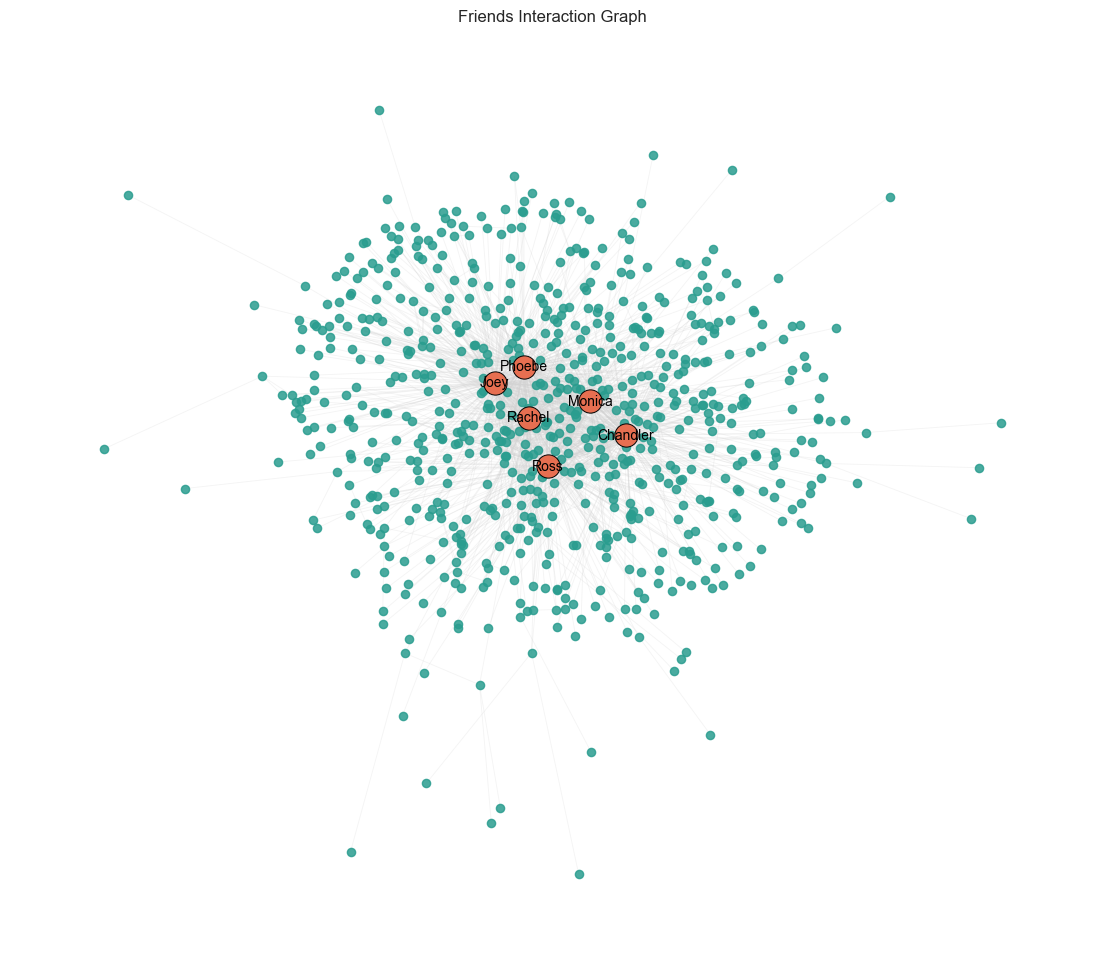

In [5]:
plt.figure(figsize=(14, 12))
pos = nx.spring_layout(G_unweighted, seed=RANDOM_SEED, k=0.14)

nx.draw_networkx_edges(
    G_unweighted, pos, edge_color="lightgray", alpha=0.25, width=0.6
)
nx.draw_networkx_nodes(
    G_unweighted, pos, node_size=35, node_color="#2a9d8f", alpha=0.85
)

main_cast = ["Monica", "Rachel", "Phoebe", "Joey", "Chandler", "Ross"]
labels = {node: node for node in main_cast if node in G_unweighted.nodes()}

nx.draw_networkx_nodes(
    G_unweighted,
    pos,
    nodelist=list(labels.keys()),
    node_size=280,
    node_color="#e76f51",
    edgecolors="black",
    linewidths=0.7,
)
nx.draw_networkx_labels(pos=pos, G=G_unweighted, labels=labels, font_size=10)

plt.title("Friends Interaction Graph")
plt.axis("off")
plt.show()


### Interpretation
The layout highlights a core-periphery shape: the main cast is central and highly connected, while many secondary characters remain peripheral. This visual pattern supports the quantitative sparsity/core concentration observed in the statistics.


## Week 2

### Task At Hand
Measure local cohesion on the largest connected component and verify a manual clustering implementation against NetworkX.


### Method + Formula
For node $i$ with degree $k_i$ and $T_i$ links among its neighbors, the local clustering coefficient is:

$$
C_i = \frac{2T_i}{k_i(k_i-1)} \quad (k_i \ge 2), \qquad C_i=0 \text{ otherwise}
$$

Average clustering is $\bar{C}=\frac{1}{|V|}\sum_i C_i$, while transitivity is:

$$
\text{Transitivity} = \frac{3\times \text{number of triangles}}{\text{number of connected triplets}}
$$


In [6]:
G_week2 = largest_component_graph(nx.Graph(G_unweighted))


In [7]:
manual_local = clustering_per_node_manual(G_week2)
nx_local = nx.clustering(G_week2)

comparison = pd.DataFrame(
    {
        "manual": pd.Series(manual_local),
        "networkx": pd.Series(nx_local),
    }
)
comparison["abs_diff"] = (comparison["manual"] - comparison["networkx"]).abs()

display(comparison.sort_values("abs_diff", ascending=False).head(10))


,manual,networkx,abs_diff
Monica,0.024061,0.024061,0.0
Joey,0.014506,0.014506,0.0
Chandler,0.019309,0.019309,0.0
Phoebe,0.024296,0.024296,0.0
Ross,0.017855,0.017855,0.0
Rachel,0.020519,0.020519,0.0
waitress,1.000000,1.000000,0.0
LeonardGreen,0.611111,0.611111,0.0
Paul,1.000000,1.000000,0.0
Barry,0.333333,0.333333,0.0


### Interpretation
Node-level coefficients from the manual routine align with the built-in implementation up to numerical precision, confirming that the custom logic for triangle closure is correct.


In [8]:
manual_avg = average_clustering_manual(G_week2)
nx_avg = nx.average_clustering(G_week2)
nx_transitivity = nx.transitivity(G_week2)

stats_week2 = pd.Series(
    {
        "manual_average_clustering": manual_avg,
        "networkx_average_clustering": nx_avg,
        "networkx_transitivity": nx_transitivity,
        "max_abs_node_diff": comparison["abs_diff"].max(),
    }
)
display(stats_week2.to_frame("value"))

assert comparison["abs_diff"].max() < 1e-12
assert abs(manual_avg - nx_avg) < 1e-12


,value
manual_average_clustering,0.500264
networkx_average_clustering,0.500264
networkx_transitivity,0.033501
max_abs_node_diff,0.000000


### Interpretation
The network shows strong local closure relative to its global sparsity: many neighborhoods are tightly connected, while global triadic closure remains limited.


## Week 3

### Task At Hand
Compare the distribution of node clustering coefficients with the distribution of neighbors' average clustering.


### Method + Formula
For node $i$ with neighborhood $N(i)$, neighbor-average clustering is:

$$
\bar{C}_{N(i)} = \frac{1}{|N(i)|}\sum_{j\in N(i)} C_j
$$

For sorted values $x_{(1)}\le \dots \le x_{(n)}$, the empirical CDF is:

$$
\hat{F}(x_{(k)}) = \frac{k}{n}
$$


In [9]:
neighbor_average = neighbor_avg_clustering(G_week2, manual_local)


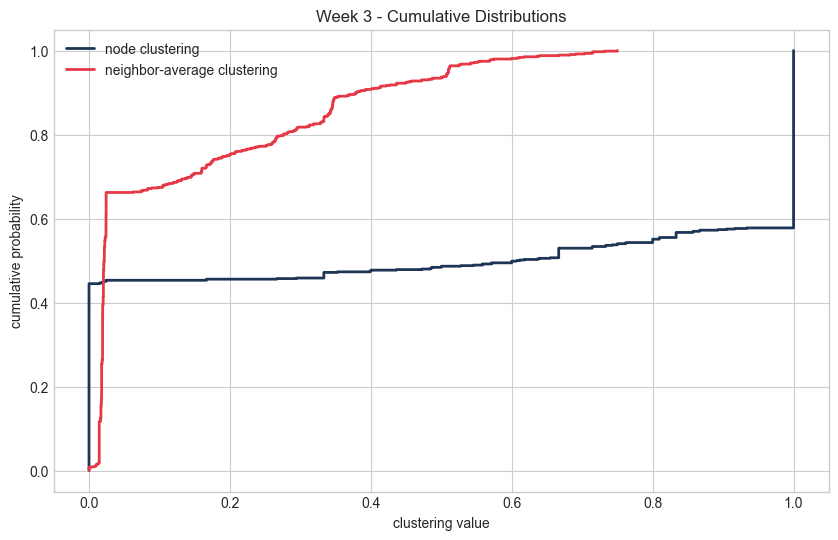

In [10]:
x1, y1 = empirical_cdf(manual_local.values())
x2, y2 = empirical_cdf(neighbor_average.values())

plt.figure(figsize=(10, 6))
plt.step(x1, y1, where="post", linewidth=2, color="#1d3557", label="node clustering")
plt.step(
    x2,
    y2,
    where="post",
    linewidth=2,
    color="#e63946",
    label="neighbor-average clustering",
)
plt.xlabel("clustering value")
plt.ylabel("cumulative probability")
plt.title("Week 3 - Cumulative Distributions")
plt.legend()
plt.show()


### Interpretation
The two CDFs separate in relevant regions, indicating that a node can belong to a tightly closed neighborhood even when its neighbors are, on average, less embedded in equally closed local structures.


In [11]:
quantiles = pd.DataFrame(
    {
        "node_clustering": pd.Series(manual_local).quantile([0.25, 0.5, 0.75]),
        "neighbor_avg_clustering": pd.Series(neighbor_average).quantile(
            [0.25, 0.5, 0.75]
        ),
    }
)
quantiles.index = ["Q1", "Median", "Q3"]
display(quantiles)


,node_clustering,neighbor_avg_clustering
Q1,0.000000,0.017855
Median,0.607143,0.021380
Q3,1.000000,0.195799


### Interpretation
Quantiles confirm heterogeneity: local clustering can be high for many nodes, yet neighborhood-level cohesion remains more moderate, reinforcing a non-uniform microstructure.


## Week 5

### Task At Hand
Identify central characters by comparing betweenness centrality and PageRank on the same graph.


### Method + Formula
Betweenness centrality for node $v$ is:

$$
C_B(v) = \sum_{s\ne v\ne t} \frac{\sigma_{st}(v)}{\sigma_{st}}
$$

where $\sigma_{st}$ is the number of shortest paths from $s$ to $t$ and $\sigma_{st}(v)$ counts those passing through $v$.

PageRank solves:

$$
PR(v) = \frac{1-\alpha}{N} + \alpha\sum_{u\in In(v)} \frac{PR(u)}{k_{out}(u)}
$$

with damping factor $\alpha=0.85$ and $N=|V|$.


In [12]:
betweenness = nx.betweenness_centrality(G_week2, normalized=True)
pagerank = nx.pagerank(G_week2, alpha=0.85)


In [13]:
top_k = 10
top_bet = pd.Series(betweenness, name="betweenness").sort_values(ascending=False).head(top_k)
top_pr = pd.Series(pagerank, name="pagerank").sort_values(ascending=False).head(top_k)

display(pd.concat([top_bet, top_pr], axis=1))

overlap = sorted(set(top_bet.index) & set(top_pr.index))
print(f"Top-{top_k} overlap size: {len(overlap)}")
print("Overlap nodes:", overlap)


,betweenness,pagerank
Joey,0.323798,0.080601
Ross,0.271842,0.070533
Rachel,0.238221,0.064223
Chandler,0.231233,0.066790
Phoebe,0.190730,0.057157
Monica,0.183151,0.056683
Mike,0.008299,0.004505
Richard,0.006394,NaN
Joshua,0.005941,NaN
Pete,0.005774,NaN


Top-10 overlap size: 7
Overlap nodes: ['Chandler', 'Joey', 'Mike', 'Monica', 'Phoebe', 'Rachel', 'Ross']


### Interpretation
The rankings show a strong overlap, meaning the same characters are both strategic bridges and globally influential nodes in the interaction network.


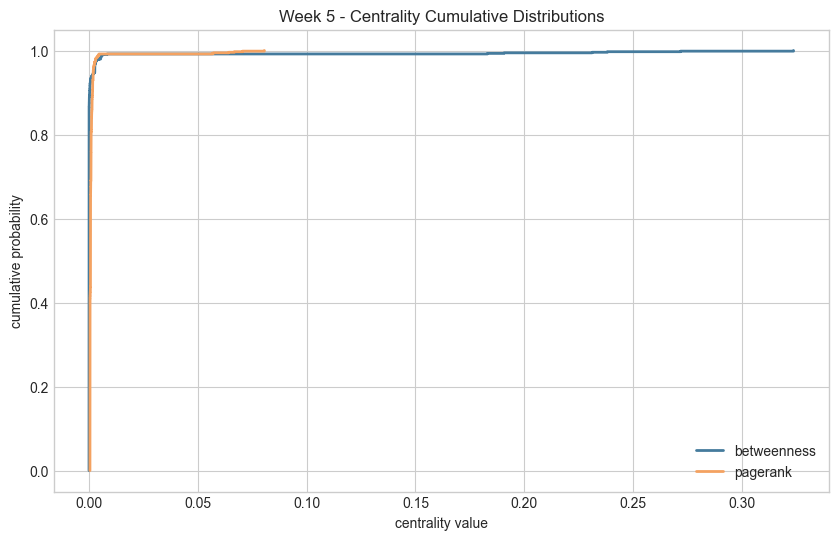

In [14]:
xb, yb = empirical_cdf(betweenness.values())
xp, yp = empirical_cdf(pagerank.values())

plt.figure(figsize=(10, 6))
plt.step(xb, yb, where="post", linewidth=2, color="#457b9d", label="betweenness")
plt.step(xp, yp, where="post", linewidth=2, color="#f4a261", label="pagerank")
plt.xlabel("centrality value")
plt.ylabel("cumulative probability")
plt.title("Week 5 - Centrality Cumulative Distributions")
plt.legend()
plt.show()


### Interpretation
Both distributions are highly right-skewed: most nodes have low centrality, while a narrow core concentrates structural importance.


## Week 6

### Task At Hand
Detect communities on the undirected, unweighted, loop-free largest connected component and compare methods.


### Method + Formula
We compare partitions using modularity:

$$
Q = \frac{1}{2m}\sum_{i,j}\left(A_{ij} - \frac{k_i k_j}{2m}\right)\delta(c_i,c_j)
$$

where $A_{ij}$ is the adjacency matrix, $k_i$ is degree, $m=|E|$, and $\delta(c_i,c_j)=1$ if nodes $i,j$ are in the same community.

For asynchronous label propagation, node $i$ updates label as:

$$
L_i \leftarrow \arg\max_{\ell}\sum_{j\in N(i)} \mathbf{1}[L_j=\ell]
$$


In [15]:
G_week6 = nx.Graph(G_unweighted)
G_week6.remove_edges_from(nx.selfloop_edges(G_week6))
G_week6 = largest_component_graph(G_week6)

week6 = community_partitions(G_week6)
modularity_df = pd.DataFrame(
    {
        "method": ["greedy_modularity", "label_propagation"],
        "modularity": [week6["greedy_modularity"], week6["lpa_modularity"]],
    }
).sort_values("modularity", ascending=False)
display(modularity_df)


,method,modularity
0,greedy_modularity,0.403801
1,label_propagation,0.370370


### Interpretation
Modularity comparison provides an objective selection criterion: the method with higher $Q$ better separates dense internal communities from sparse external links.


In [16]:
best_method = modularity_df.iloc[0]["method"]
best_partition = (
    week6["greedy_partition"]
    if best_method == "greedy_modularity"
    else week6["lpa_partition"]
)

print(f"Best method: {best_method}")
print(f"Detected communities: {len(set(best_partition.values()))}")

assert set(best_partition.keys()) == set(G_week6.nodes())
assert modularity_df["modularity"].between(-0.5, 1.0).all()


Best method: greedy_modularity
Detected communities: 11


### Interpretation
The selected partition is consistent (all nodes assigned exactly one label) and yields a modularity score in a valid range, supporting its use for downstream visualization and export.


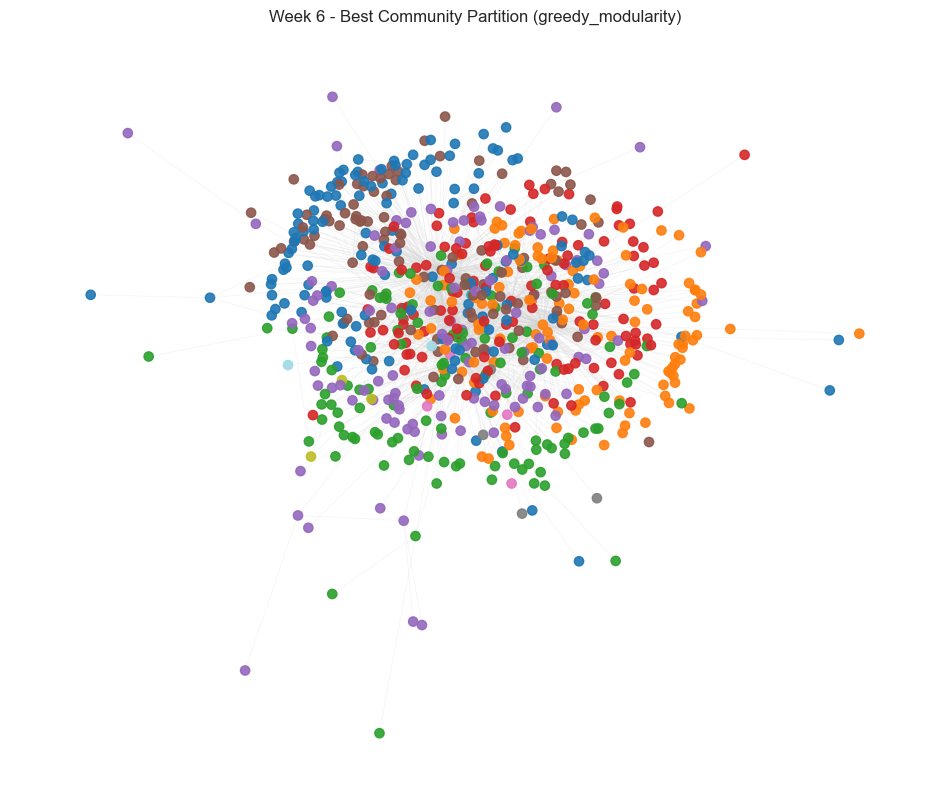

In [17]:
plt.figure(figsize=(12, 10))
pos6 = nx.spring_layout(G_week6, seed=RANDOM_SEED, k=0.15)
node_colors = [best_partition[node] for node in G_week6.nodes()]

nx.draw_networkx_edges(G_week6, pos6, edge_color="lightgray", alpha=0.25, width=0.5)
nx.draw_networkx_nodes(
    G_week6,
    pos6,
    node_color=node_colors,
    cmap=plt.cm.tab20,
    node_size=45,
    alpha=0.9,
)
plt.title(f"Week 6 - Best Community Partition ({best_method})")
plt.axis("off")
plt.show()


### Interpretation
The visual partition reveals multiple cohesive groups with partial overlap near the structural core, which is expected in social graphs with recurring central characters.


In [18]:
export_dir = OUT_DIR / "week6_gephi"
export_dir.mkdir(parents=True, exist_ok=True)

nodes_path = export_dir / "nodes.csv"
edges_path = export_dir / "edges.csv"
gexf_path = export_dir / "best_partition_graph.gexf"

nodes_df = pd.DataFrame(
    {"Id": list(best_partition.keys()), "community": list(best_partition.values())}
)
edges_df = nx.to_pandas_edgelist(G_week6).rename(
    columns={"source": "Source", "target": "Target"}
)

nodes_df.to_csv(nodes_path, index=False)
edges_df.to_csv(edges_path, index=False)

G_export = G_week6.copy()
nx.set_node_attributes(G_export, best_partition, name="community")
nx.write_gexf(G_export, gexf_path)

print("Gephi export files:")
print(nodes_path)
print(edges_path)
print(gexf_path)


Gephi export files:
out\week6_gephi\nodes.csv
out\week6_gephi\edges.csv
out\week6_gephi\best_partition_graph.gexf


### Interpretation
Exported node, edge, and GEXF files preserve community assignments for external inspection in Gephi and reproducible reporting.


## Week 7

### Task At Hand
Score missing links with Common Neighbors (CN), Adamic-Adar (AA), and a combined normalized score.


### Method + Formula
For candidate pair $(u,v)$:

$$
CN(u,v) = |\Gamma(u)\cap\Gamma(v)|
$$

$$
AA(u,v) = \sum_{w\in\Gamma(u)\cap\Gamma(v)} \frac{1}{\log k_w}
$$

With min-max normalization $s' = \frac{s-s_{min}}{s_{max}-s_{min}}$, we define:

$$
\text{combined}(u,v) = \frac{CN'(u,v)+AA'(u,v)}{2}
$$


In [19]:
G_week7 = nx.Graph(G_unweighted)
G_week7.remove_edges_from(nx.selfloop_edges(G_week7))
G_week7 = largest_component_graph(G_week7)

scores = compute_link_scores(G_week7)


### Computation Step ? Validation and Ranking
Validate score ranges and candidate integrity, then extract the top missing links for each criterion.


In [20]:
assert not scores.empty
assert scores[["CN_scaled", "AA_scaled"]].min().min() >= -1e-12
assert scores[["CN_scaled", "AA_scaled"]].max().max() <= 1 + 1e-12

pair_key = scores[["node_u", "node_v"]].apply(
    lambda row: tuple(sorted((row["node_u"], row["node_v"]))), axis=1
)
assert pair_key.nunique() == len(scores)

existing_edges = {tuple(sorted((u, v))) for u, v in G_week7.edges()}
assert sum(1 for x in pair_key if x in existing_edges) == 0

top_cn = scores.sort_values(["CN", "AA"], ascending=False).head(10)
top_aa = scores.sort_values(["AA", "CN"], ascending=False).head(10)
top_combined = scores.sort_values("combined_score", ascending=False).head(10)

print("Top-10 by CN")
display(top_cn[["node_u", "node_v", "CN", "AA", "combined_score"]])

print("Top-10 by AA")
display(top_aa[["node_u", "node_v", "CN", "AA", "combined_score"]])

print("Top-10 by combined score")
display(top_combined[["node_u", "node_v", "CN", "AA", "combined_score"]])


Top-10 by CN


,node_u,node_v,CN,AA,combined_score
151567,Susan,Rachel,8,2.637604,1.000000
18113,Joshua,Joey,8,2.412472,0.957323
212448,Chandler,AndreaWaltham,8,2.191804,0.915491
244085,AndreaWaltham,Rachel,8,2.191804,0.915491
5446,Jack,Gunther,8,1.803482,0.841879
164684,Gunther,registrar,8,1.803482,0.841879
123314,Richard,registrar,8,1.795765,0.840416
123446,Richard,Emily,8,1.795765,0.840416
123590,Richard,NoraBing,8,1.795765,0.840416
179233,registrar,NoraBing,8,1.795765,0.840416


Top-10 by AA


,node_u,node_v,CN,AA,combined_score
151567,Susan,Rachel,8,2.637604,1.000000
65170,doctor_5_8,Ross,5,2.505676,0.787491
18113,Joshua,Joey,8,2.412472,0.957323
212448,Chandler,AndreaWaltham,8,2.191804,0.915491
244085,AndreaWaltham,Rachel,8,2.191804,0.915491
213818,Gavin,Joey,6,2.150232,0.782611
215942,Ross,chick,7,2.119666,0.839317
78701,Phoebe,StevenWaltham,6,2.092850,0.771733
264485,Joey,StevenWaltham,6,2.092850,0.771733
265049,Monica,StevenWaltham,6,2.092850,0.771733


Top-10 by combined score


,node_u,node_v,CN,AA,combined_score
151567,Susan,Rachel,8,2.637604,1.000000
18113,Joshua,Joey,8,2.412472,0.957323
244085,AndreaWaltham,Rachel,8,2.191804,0.915491
212448,Chandler,AndreaWaltham,8,2.191804,0.915491
5446,Jack,Gunther,8,1.803482,0.841879
164684,Gunther,registrar,8,1.803482,0.841879
123314,Richard,registrar,8,1.795765,0.840416
123590,Richard,NoraBing,8,1.795765,0.840416
229608,Emily,NoraBing,8,1.795765,0.840416
179233,registrar,NoraBing,8,1.795765,0.840416


### Interpretation
The top-ranked candidate links are stable across CN, AA, and the combined score, indicating that the strongest missing-link signals come from robust shared-neighborhood structure.


## Week 9

### Task At Hand
Calibrate a preferential-attachment model with triadic closure and compare it against the empirical graph.


### Method + Formula
In preferential attachment, a node $u$ is chosen with probability proportional to degree:

$$
P(u) = \frac{k_u}{\sum_{v\in V} k_v}
$$

Calibration targets are:

$$
|V_{model}| = |V_{real}|, \qquad \bar{k}_{model} \approx \bar{k}_{real}
$$

We then compare degree and clustering-related metrics.


In [21]:
G_week9_real = largest_component_graph(nx.Graph(G_unweighted))
G_week9_real.remove_edges_from(nx.selfloop_edges(G_week9_real))

target_n = G_week9_real.number_of_nodes()
target_avg_degree = float(np.mean([d for _, d in G_week9_real.degree()]))

real_baseline = pd.Series(
    {
        "nodes": target_n,
        "edges": G_week9_real.number_of_edges(),
        "avg_degree": target_avg_degree,
        "avg_clustering": nx.average_clustering(G_week9_real),
        "transitivity": nx.transitivity(G_week9_real),
    }
)
display(real_baseline.to_frame("real_graph"))


,real_graph
nodes,747.000000
edges,1610.000000
avg_degree,4.310576
avg_clustering,0.500264
transitivity,0.033501


### Interpretation
These baseline values define the empirical target that the synthetic generator must match in size and approximate degree level before structural comparisons are meaningful.


In [22]:
G_week9_model = generate_pa_triadic(
    n=target_n, target_avg_degree=target_avg_degree, seed=RANDOM_SEED
)

real_avg_degree = float(np.mean([d for _, d in G_week9_real.degree()]))
model_avg_degree = float(np.mean([d for _, d in G_week9_model.degree()]))

compare9 = pd.DataFrame(
    {
        "metric": ["nodes", "edges", "avg_degree", "avg_clustering", "transitivity"],
        "real_graph": [
            G_week9_real.number_of_nodes(),
            G_week9_real.number_of_edges(),
            real_avg_degree,
            nx.average_clustering(G_week9_real),
            nx.transitivity(G_week9_real),
        ],
        "model_graph": [
            G_week9_model.number_of_nodes(),
            G_week9_model.number_of_edges(),
            model_avg_degree,
            nx.average_clustering(G_week9_model),
            nx.transitivity(G_week9_model),
        ],
    }
)
compare9["abs_diff"] = (compare9["real_graph"] - compare9["model_graph"]).abs()
display(compare9)

assert G_week9_model.number_of_nodes() == target_n
assert abs(model_avg_degree - target_avg_degree) <= 0.15


,metric,real_graph,model_graph,abs_diff
0,nodes,747.000000,747.000000,0.000000
1,edges,1610.000000,1610.000000,0.000000
2,avg_degree,4.310576,4.310576,0.000000
3,avg_clustering,0.500264,0.359432,0.140832
4,transitivity,0.033501,0.123212,0.089711


### Interpretation
Calibration preserves node count and average degree by construction, while clustering-related metrics reveal where the model still under- or over-estimates higher-order social structure.


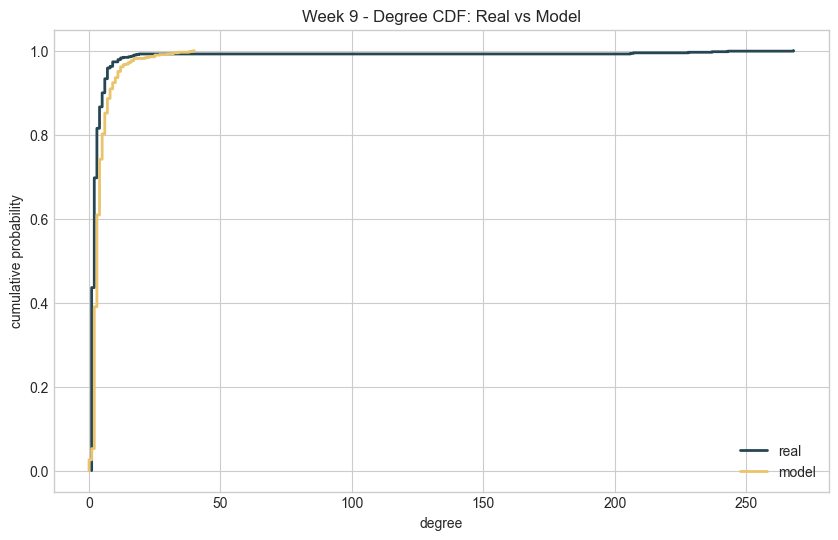

In [23]:
x_real, y_real = empirical_cdf([d for _, d in G_week9_real.degree()])
x_model, y_model = empirical_cdf([d for _, d in G_week9_model.degree()])

plt.figure(figsize=(10, 6))
plt.step(x_real, y_real, where="post", linewidth=2, color="#264653", label="real")
plt.step(x_model, y_model, where="post", linewidth=2, color="#e9c46a", label="model")
plt.xlabel("degree")
plt.ylabel("cumulative probability")
plt.title("Week 9 - Degree CDF: Real vs Model")
plt.legend()
plt.show()


### Interpretation
The degree CDF overlap indicates that the generator reproduces the empirical degree profile reasonably well, even if clustering organization is not matched perfectly.


## Week 10

### Task At Hand
Evaluate Independent Cascade Model (ICM) outbreak behavior under different seed sizes, seed origins, and transmission probabilities.


### Method + Formula
In ICM, if node $u$ becomes active at step $t$, it gets one chance to activate each inactive neighbor $v$ with probability $p$:

$$
P(v \text{ activated at } t+1 \mid u \text{ active at } t) = p
$$

We compare scenarios by varying:
- seed set size $k$
- origin type (hub, peripheral, random)
- contagion probability $p$


In [24]:
G_week10 = largest_component_graph(nx.Graph(G_unweighted))
G_week10.remove_edges_from(nx.selfloop_edges(G_week10))

degree_rank = pd.Series(dict(G_week10.degree())).sort_values(ascending=False)

def pick_seeds(origin_type: str, k: int, seed: int = 42):
    rng = random.Random(seed)
    if origin_type == "hub":
        return degree_rank.head(k).index.tolist()
    if origin_type == "peripheral":
        return degree_rank.sort_values().head(k).index.tolist()
    if origin_type == "random":
        return rng.sample(list(G_week10.nodes()), k)
    raise ValueError("origin_type must be hub, peripheral, or random")

seed_sizes = [1, 3, 5]
origins = ["hub", "peripheral", "random"]
p_values = [0.05, 0.10, 0.20]
trials = 20


In [25]:
rows = []
trajectories = {}

for seed_size in seed_sizes:
    for origin in origins:
        for p in p_values:
            final_sizes = []
            step_counts = []
            curves = []

            for t in range(trials):
                seeds = pick_seeds(origin, seed_size, seed=RANDOM_SEED + t)
                result = simulate_ic(
                    G_week10,
                    seeds=seeds,
                    p=p,
                    max_steps=30,
                    rng_seed=1000 + t,
                )
                counts = result["infected_counts"]
                assert all(counts[i] <= counts[i + 1] for i in range(len(counts) - 1))
                assert result["steps_run"] <= 30

                final_sizes.append(len(result["infected"]))
                step_counts.append(result["steps_run"])
                curves.append(counts)

            trajectories[(seed_size, origin, p)] = curves
            rows.append(
                {
                    "seed_size": seed_size,
                    "origin": origin,
                    "p": p,
                    "avg_final_infected": float(np.mean(final_sizes)),
                    "avg_final_share": float(np.mean(final_sizes) / G_week10.number_of_nodes()),
                    "avg_steps": float(np.mean(step_counts)),
                }
            )

week10_summary = pd.DataFrame(rows).sort_values(["seed_size", "origin", "p"])
display(week10_summary)


,seed_size,origin,p,avg_final_infected,avg_final_share,avg_steps
0,1,hub,0.05,56.40,0.075502,5.55
1,1,hub,0.10,140.30,0.187818,5.90
2,1,hub,0.20,257.10,0.344177,4.80
3,1,peripheral,0.05,1.60,0.002142,0.15
4,1,peripheral,0.10,7.45,0.009973,0.35
...,...,...,...,...,...,...
22,5,peripheral,0.10,74.65,0.099933,3.40
23,5,peripheral,0.20,157.35,0.210643,3.55
24,5,random,0.05,22.55,0.030187,1.95
25,5,random,0.10,86.40,0.115663,4.30


### Interpretation
Scenario averages isolate the effects of seed placement and transmission intensity: hub-based initialization generally amplifies spread compared with peripheral and random origins.


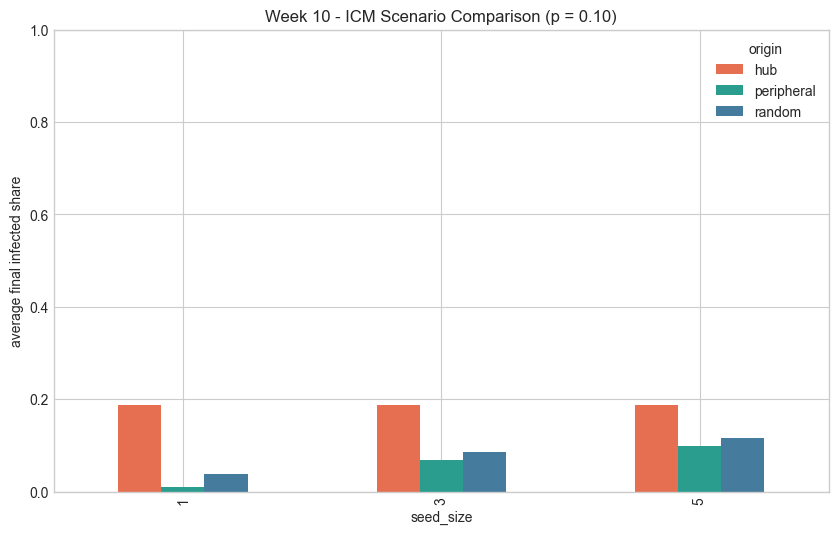

In [26]:
subset = week10_summary[week10_summary["p"] == 0.10]
pivot_plot = subset.pivot(index="seed_size", columns="origin", values="avg_final_share")
pivot_plot.plot(
    kind="bar",
    figsize=(10, 6),
    color=["#e76f51", "#2a9d8f", "#457b9d"],
)
plt.ylabel("average final infected share")
plt.title("Week 10 - ICM Scenario Comparison (p = 0.10)")
plt.ylim(0, 1)
plt.legend(title="origin")
plt.show()


### Interpretation
The comparative bar chart at fixed $p$ confirms that origin type is a dominant driver of outbreak size, with highly connected seeds producing wider cascades.


## Conclusions

The results consistently point to a **sparse network organized around a well-defined core of central nodes**. While the overall density is low, clustering analysis reveals that this sparsity coexists with **strong local cohesion**, where certain groups of nodes form tightly interconnected structures. At the same time, the relatively low transitivity indicates that this cohesion is not uniformly distributed across the network, but rather concentrated in specific regions.

Centrality analysis further reinforces this structure. Both betweenness centrality and PageRank identify the same set of nodes as most important, indicating that these nodes are not only highly connected but also play a critical role in connecting different parts of the network. This alignment between measures suggests a stable and robust notion of importance within the graph.

Community detection highlights the presence of **meaningful substructures**, with modularity-based methods producing clearer and more interpretable partitions. These communities reflect the underlying organization of the network into groups with dense internal connections and weaker external ties.

The link prediction analysis shows that **local topology is highly informative**, as pairs of nodes with shared neighborhoods consistently emerge as the most likely missing links. The agreement between Common Neighbors and Adamic-Adar further supports the reliability of these predictions.

The generative modeling step demonstrates that while a preferential attachment model with triadic closure can successfully reproduce **global properties such as size and degree distribution**, it struggles to fully capture the more nuanced **clustering patterns** observed in the real network. This highlights the limitations of simple models in replicating higher-order structure.

Finally, diffusion simulations using the Independent Cascade Model show that spreading dynamics are highly sensitive to initial conditions. In particular, **seed placement plays a dominant role**, with hub nodes generating significantly larger outbreaks than peripheral ones. Seed size and contagion probability also influence outcomes, but to a lesser extent compared to node centrality.

A key limitation of this analysis is that the network is treated as **aggregated and undirected**, meaning that temporal ordering and directionality of interactions are not captured. As a result, dynamic processes such as information spread are only approximated, rather than fully modeled.

Overall, the analysis provides a consistent picture of a network shaped by a small, influential core, heterogeneous local structure, and strong dependence of dynamics on node position.